A continuación se realiza una breve descripción de este proyecto que realizaremos para una tienda de videojuegos llamada "ICE".

Trabajas para la tienda online Ice que vende videojuegos por todo el mundo. Las reseñas de usuarios y expertos, los géneros, las plataformas (por ejemplo, Xbox o PlayStation) y los datos históricos sobre las ventas de juegos están disponibles en fuentes abiertas. Tienes que identificar patrones que determinen si un juego tiene éxito o no. Esto te permitirá detectar proyectos prometedores y planificar campañas publicitarias.

Delante de ti hay datos que se remontan a 2016. Imaginemos que es diciembre de 2016 y estás planeando una campaña para 2017.

Lo importante es adquirir experiencia de trabajo con datos. Realmente no importa si estás pronosticando las ventas de 2017 en función de los datos de 2016 o las ventas de 2027 en función de los datos de 2026.

In [1]:
# Se inicia con la carga de librerías.

import pandas as pd
import numpy as np
from math import factorial
from scipy import stats as st
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy.stats as stats

In [5]:
# Se realiza la carga del dataset con el que estaremos trabajando y que nos proporcino la tienda 'Ice' para llevar a cabo el 
# análisis de datos correspondiente cubriendo cada una de las necesidades expuestas por esta tienda de videojuegos.

url1 = 'https://drive.google.com/uc?export=download&id=13zIx2_tnUIg6h9L6uo0HCCCWMEUTi1Wh'
df_games = pd.read_csv(url1)

In [7]:
# Se visualiza el dataset para iniciar con el Data cleaning correspondiente.
df_games.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [9]:
# En esta primera parte realizaremos una Estandarización de encabezados en cada columna del dataset pasando a minúsculas y 
# usando un formato snake_case para cada una de estas.

df_games = df_games.rename(columns = {
    'Name': 'name',
    'Platform': 'platform',
    'Year_of_Release': 'year_of_release',
    'Genre': 'genre',
    'NA_sales': 'na_sales',
    'EU_sales': 'eu_sales',
    'JP_sales': 'jp_sales',
    'Other_sales': 'other_sales',
    'Critic_Score': 'critic_score',
    'User_Score': 'user_score',
    'Rating': 'rating'
})
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [11]:
# Teniendo una Estandarización de encabezados realizamos un Type Conversation y Casting para optmizar el flujo analítico

df_games['user_score'] = pd.to_numeric(df_games['user_score'], errors='coerce')
df_games = df_games.astype({ 'year_of_release': 'Int64',
                             'critic_score': 'Int64', 
                             'name': 'object', 
                             'platform': 'category', 
                             'genre': 'category', 
                             'rating': 'object' }) 
df_games.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16713 non-null  object  
 1   platform         16715 non-null  category
 2   year_of_release  16446 non-null  Int64   
 3   genre            16713 non-null  category
 4   na_sales         16715 non-null  float64 
 5   eu_sales         16715 non-null  float64 
 6   jp_sales         16715 non-null  float64 
 7   other_sales      16715 non-null  float64 
 8   critic_score     8137 non-null   Int64   
 9   user_score       7590 non-null   float64 
 10  rating           9949 non-null   object  
dtypes: Int64(2), category(2), float64(5), object(2)
memory usage: 1.2+ MB


In [12]:
# Se realiza una busqueda de valores ausentes, nulos o faltantes dentro del dataset 'games'.
df_games.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

Nota. Se detectan valores ausentes o nulos para lo cual tendremos que analizar como vamos a tratar estos valores, haremos uso 
de los comandos '.dropna e .isna' con el objetivo de tener un análisis más fluido y un procesamiento eficiente de los datos.

In [13]:
df_games.dropna(subset=['name', 'year_of_release', 'genre'], inplace=True)
df_games['rating'] = df_games['rating'].fillna('Unknown')
df_games.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         8981
rating                0
dtype: int64

Resultados importantes del Data cleaning.

El tratamiento sobre los datos de un dataset es importante puesto que de ellos se realizan insights que ayudaran a la tienda "ICE" en el respaldo de la toma de decisiones, por tal razón el tratamiento de datos ausentes en las columnas 'name', 'year_of_release' y 'genre'. Fue eliminarlos ya que la cantidad en las columnas 'name' y 'genre' es minima y no causará un impacto notable dentro de la fase de análisis por otro lado la columna 'year_of_release' también se tomo la misma decisión a pesar de la gran cantidad de datos que tenía jugando en su contra y por ultimo la columna 'rating' en sus valores ausentes se hizo un reemplazo por 'unknown'

In [14]:
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,<NA>,NaN,Unknown
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,<NA>,NaN,Unknown


Respondiendo a las preguntas por la tienda online 'Ice'.
¿Cuáles son las causas principales de la presencia de valores ausentes (datos faltantes) en nuestro conjunto de datos y cómo afectan el análisis de la tienda online?
* Omisión por parte del usuario: El cliente o administrador no proporcionó el dato de manera opcional durante su interacción (por ejemplo, omitir la reseña, la edad o el correo secundario al registrarse).
* Definición de reglas de negocio en la interfaz: Campos que no se configuraron como obligatorios en la plataforma web o móvil, permitiendo la creación de registros incompletos por diseño.
* Incidencias técnicas o fallas del sistema (bugs): Interrupciones temporales en el sistema o en la canalización de datos (ETL) que provocaron la pérdida o no sobrescritura de atributos previamente existentes en momentos específicos.

In [15]:
# La tienda 'Ice' esta solicitando que obtengamos el total de las ventas y para obtener este resultado lo trabajamos bajo el
# siguiente codigo.

df_games['total_sales']= df_games[['na_sales', 'eu_sales', 'jp_sales', 'other_sales' ]].sum(axis=1)
df_games

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,<NA>,NaN,Unknown,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,<NA>,NaN,Unknown,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,<NA>,NaN,Unknown,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,<NA>,NaN,Unknown,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,<NA>,NaN,Unknown,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,<NA>,NaN,Unknown,0.01


La empresa online 'Ice' quiere que nos enfoquemos en la siguiente información y en base a la misma trazar una grafica que ayude a sostener nuestras afirmacions sobre la misma, optimizando memoria y mejorando la precisón y fluidez del análisis.

Respondiendo al primer inciso del paso tres , donde podemos observar que los datos de lanzamiento por año nos percatamos de un patrón que esta muy marcado sobre todo en la cantidad de juegos, mi análisis de datos se basa en tres puntos importantes y que es preciso mencionar cada uno de estos puntos:

Mí análisis inicia durante los años 80's y 90's: En donde se puede ver claramente que los datos que manejaban en esos años eran muy escasos por la principal razón de la industria era demasiado pequeña. Y que el dataset solia centrarse y enfocarse en reacabar solomante éxitos comerciales que tenían ventas masivas durante estos años.

Después de los años 80's y 90's pasamos al periodo que fue de los 2000 a 2010: Y a diferencia de los años pasados, se puede decir con certeza que está decada es donde se logro ver una gran alza en ventas y que esto se vio reflejado en las ganancias debío a que las compañias dedicadas a la fabricación de consolas de videojuegos daban pie a la llegada de las consolas que revolucionaría la industria de los videojuegos claro estamos hablando de que llegaban al mercado las consolas PS2, DS y Wii.

Para terminar de responder al primer inciso cerrare con el periodo corto que fue del 2011 al 2016: En este periodo se mira con atención que siguén siendo años con muchso datos positivos sin embargo con una pequeña peculiaridad que es, que el dataset se empieza a estabilizar y baja ligeramente ya que el 2016 es el año en donde termina este dataset.

De igual manera respondiendo a la pregunta de que ¿Son significativos los datos de cada uno de los periodos? La respuesta a está pregunta es la siguiente:

Por el lado estadístico: Considero que el periodo de los 80's y 90's sus resultados no son tan relevantes ya que son pocos datos que puede ayudar a un análisis exahustivo y bien estructurado por lo mismo no considero tan importante los resultados de este periodo, sin embargo si considero de gran relevancia e importancia todos los datos que surgieron a partir de los años 2000 en adelante hasta el año 2016 ya que fueron años donde la tecnología daba inicio a su evolución hablando en temas de fabricación de consolas de videojueos ya que claramete se ve en los numeros positivos durante todos estos años aunado a esto por el tema de la tendencia podemos decir que los años 2000 fueron de gran impacto y que todo esto en conjunto ayudan a sacar resultados y conclusiones solidas basadas en datos reales y concretos cabe mencionar que todo esto fue principalmente enfocado en ventas físicas sin embargo no obstante sabemos que la evolución digital empezo a reemplazar los videojuegos en formato fisico obligando al usuario a trasladarse al mundo digital lo que repercute de cierta manera los datos de los ultimos años que van desde el año 2013 al 2016 donde se da fin a este dataset.

Desglozando el inciso numero dos y respondiendo de forma parcial mi análisis es el siguiente:

Elegir las plataformas con las mayores ventas totales y construir una distribucion basada en los datos de cada año: Como bien lo mencione en el inciso anterior que las consolas lideres que dejaron y siguen haciendo historia han acumulado grandes ventas y masivas por decir asi en donde destacan las siguientes consolas:
PS2: El rey indiscutiblemente quien acumulo un total de 1,250 millones en ventas totales netas.
X360 y PS3: estos gigantes de las consolas tambien estan dentro de la lista de lideres en ventas con casi 950 millones.
Por ultimo los dos y no menos importantes están Wii y DS que alcanza a superar los 800-900 millones, donde los titulos como Wii Sports jugaron un papel importante para alcanzar estas cifras.
Construccion de una distribución basada en los datos de cada año: Al revisar de forma detenida los resultados que arrojo la distrubución por año, es evidente que hay un patrón de "campana". Esto quiere decir que las plataformas que tendían a ser las más populares dentro del mercado de los videojuegos para el 2016 mostraron ya no contar con las ventas significativas que en años atras tenían la lista esta conformada por:
DS: dentro de la distribución de campana logramos ver que esta plataforma tuve su auge entre 2005 hasta el 2010; algo que suele suceder con las plataformas dentro de sus primeros 3 y 6 años de lanzamiento posteriormente a esto si la plataforma no logra mantenerse en ese auge lo que sigue es a ver un gran declive gradual y esto paso para el 2014 donde sus ventas ya empezaban a ser inexistentes.

PS2: El rey que por una decada domino este gran mercado, sin embargo como todo tiene un incio tambien tiene un final y para PS2 se llego para hacía el 2011 desapareciendo por completo del mercado de videojuegos.

Wii: tras unas excelentes ventas en el 2006 hasta el 2009, estas cayeron de forma drastica claro esto provocado por la llegada de la siguiente generación de consolas para videojuegos.

¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?: Respondiendo a esta pregunta lo hago de la siguiente manera:
Una plataforma tarda normalmente entre 10 a 12 años esto partiendo desde el punto de que aparace hasta aque llega a su fin de vida y a esto le llama "Vida útil de la plataforma".

Como ya lo mencione anteriormente las nuevas consolas que saca al mercado el fabricante, al fabricante le lleva un tiempo estimado de entre 5 a 7 años en hacer publicidad mencionando la fecha de lanzimiento de su nuevo producto ya se en temrinos de videojuegos o consolas, tenemos el claro ejemplo de PS2 que fue sustituido por PS3 y así sucesivamente hasta la actualidad.

Y para que una plataforma alcance su madurez dentro del mundo de los videojuegos se lleva un tiempo estimado entre los 3 a 6 años desde su lanzamiento.

Para representar de mejor manera todo lo mencionado en este punto se realizo la siguiente grafica para mejorar el análisis y tener una apresiación sobre todo lo que a cabo de mencionar.



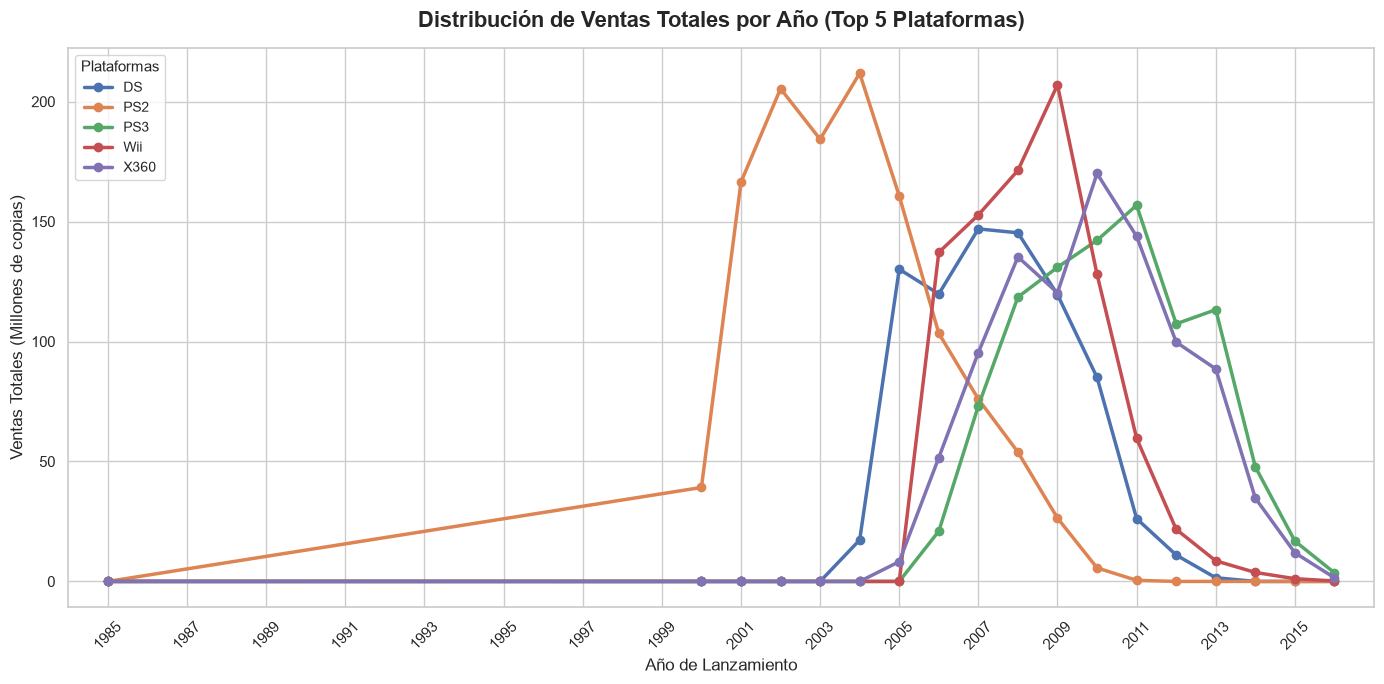

In [17]:
# A continuación, se presenta la gráfica de distribución generada a partir del subconjunto de datos procesado en el punto anterior, 
#con el fin de evaluar el comportamiento y la dispersión de [Variable / Métrica].
df_games["year_of_release"] = pd.to_numeric(df_games["year_of_release"], errors="coerce")
df_games["total_sales"] = pd.to_numeric(df_games["total_sales"], errors="coerce")

df_games = df_games.dropna(subset=["year_of_release"])
df_games["year_of_release"] = df_games["year_of_release"].astype(int)

top_platforms = (
    df_games.groupby("platform")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

df_top = df_games[df_games["platform"].isin(top_platforms)]

ventas_anuales = (
    df_top.groupby(["year_of_release", "platform"])["total_sales"]
    .sum()
    .unstack()
    .fillna(0)
)

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

for plataforma in ventas_anuales.columns:
    plt.plot(
        ventas_anuales.index,
        ventas_anuales[plataforma],
        marker="o",
        linewidth=2.5,
        label=plataforma,
    )

plt.title(
    "Distribución de Ventas Totales por Año (Top 5 Plataformas)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Año de Lanzamiento", fontsize=12)
plt.ylabel("Ventas Totales (Millones de copias)", fontsize=12)
plt.xlim(
    ventas_anuales.index.min() - 1, ventas_anuales.index.max() + 1
)  # Ajustar eje X
plt.xticks(
    np.arange(ventas_anuales.index.min(), ventas_anuales.index.max() + 1, 2),
    rotation=45,
)
plt.legend(title="Plataformas", title_fontsize="11", fontsize="10", loc="upper left")
plt.tight_layout()

# Mostrar gráfica
plt.show()

Solución al inciso tres que solicita lo siguiente "Determina para qué período debes tomar datos. Para hacerlo mira tus respuestas a las preguntas anteriores. Los datos deberían permitirte construir un modelo para 2017."

En base al análisis de datos que llevamos hasta ahora, podemos construir el modelo para el 2017 y para esto utilizaremos datos que nos son mas factibles y viables para construirlo y estos datos son de los periodos 2013-2016 y a continuación explicare el porque de esta decisión de tomar los periodos del 2013 al 2016, cabe mencionar que todo esta basado principalmente en el ciclo de vida de las consolas.

Como primer punto está la parte de la Importancia de la Generación Actual: como bien vimos en el año 2013 las empresas fabricantes de consolas de videojuegos lanzaron al mercado PS4 y Box One. El tomar datos desde la perspectiva de consolas y especificamente desde este año (2013) permite una mejor captación en el crecimiento que exisitio sin dejar a un lado la etapa del auge de las plataformas que dominaran el tema de las ventas para el 2017.
Tema Historico: El tema historico no tiene mayor relvenacia para construir el periodo 2017. Hoy en día no es importante y no hay impacto alguno el saber la historia detras de las plataformas y consolas por la razón principal de que historia estó no va a venir a sumar al periodo que necesitamos, y lo que realmente se necesita es saber como se menciono en el primer punto las platadormas que dejaran grandes ventas para el 2017, y saber que PS2 tuvo una decada de gloria donde su tiempo de vida útil por los usuarios estaba ya definidida. Entonces el tema Historico queda descartado por completo.
Vida útil de la plataforma: En el inciso o punto 2 hable sobre el tiempo que tarda una plataforma en ser reeemplazada por una nueva versión mas sofisticada y que este tiempo puede ir desde los 5 a 7 años, sin embargo los periodos que tomamos son mas cortos por cual se tomara un indicador de 3 a 4 años que son indicadores mas precisos de todas las tendencias de consumo en tiempo real.
Vigencia de los datos: Como bien se observo el dataset solo llega hasta el 2016, lo que deja un margen de 4 años lo que resulta suficientemente extenso que ayudara a mostrar taryectoria de ventas pero al mismo tiempo corto lo que representa una desventaja ya que reduce el espacio para ignorar dinámicas de mercado ya inhabilitadas.
Solución al inciso cuatro: "Trabaja solo con los datos que consideras relevantes. Ignora los datos de años anteriores.": Es muy importaante saber y conocer con el tipo de datos con los que estamos trabajando o se va a atrabajar, para ello y para enriquecer el análisis de datos se decidio que era realmente irrelevante continuar con datos que no van a sumar al periodo que queremos elaborar para el 2017 a lo cual llamamos "Obsolescencia de los datos" y esto permitira enfocar el modelo 2017 haciá la dinámica del mercado moderno.

Para ejemplificar este inciso se hizo lo siguiente se implemento el codigo que nos permitira hacer lo siguiente:



In [18]:
# Se Filtran los años que se escogieron para trabajar en este modelo 2017
df_relevante = df_games[df_games['year_of_release'] >= 2013]
# Agrupamos por plataforma que ayudara y optimizara la forma de identificar líderes del período.
ventas_plataforma = (
    df_relevante.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
)

df_relevante['critic_score'] = df_relevante['critic_score'].astype(float)
# ventas_plataforma
df_relevante.info()

<class 'pandas.DataFrame'>
Index: 2233 entries, 16 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             2233 non-null   object  
 1   platform         2233 non-null   category
 2   year_of_release  2233 non-null   int64   
 3   genre            2233 non-null   category
 4   na_sales         2233 non-null   float64 
 5   eu_sales         2233 non-null   float64 
 6   jp_sales         2233 non-null   float64 
 7   other_sales      2233 non-null   float64 
 8   critic_score     991 non-null    float64 
 9   user_score       1192 non-null   float64 
 10  rating           2233 non-null   object  
 11  total_sales      2233 non-null   float64 
dtypes: category(2), float64(7), int64(1), object(2)
memory usage: 197.8+ KB


Respondiendo al inciso numero cinco: Decimos que basado en el nuevo subconjunto de información (nueva tabla) con los periodos previamente selaccionados basados en un análisis exahustivo me permito mostrar el análisis que nos permitira visualizar las plataformas líderes y con ello determinar su factibilidad comercial de cara a 2017.

Plataformas Líderes en Ventas Reales y Totales: al revisar este nuevo conjunto de datos, podemos observar claramente que los títulos de videojuegos con una alta recopilación de datos como lo son (Grand Theft Auto, Call Of Duty: Black Ops 3), para ello lo demostramos graficamente para que se tenga una visualización mas clara y objetiva.


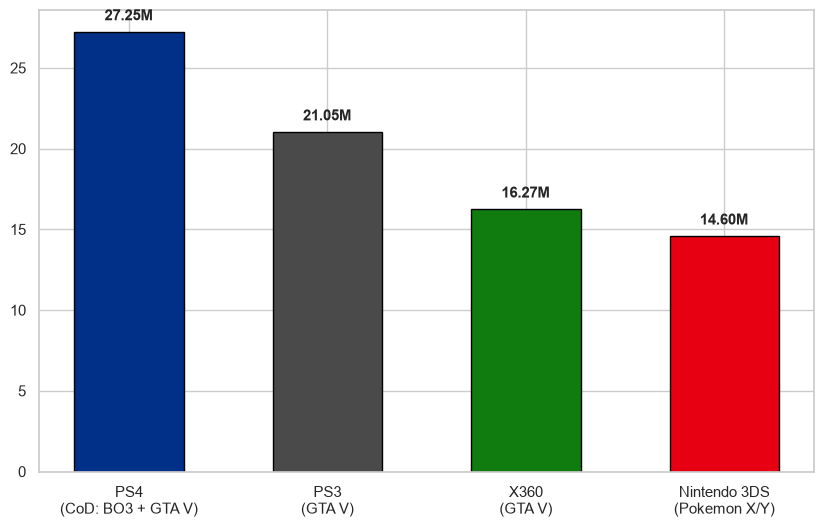

In [19]:
# A continuación, se presenta la visualización de datos que sintetiza los hallazgos descritos anteriormente. 

grafica_plataformas = {
    'Plataforma': [
      "PS4\n(CoD: BO3 + GTA V)",
        "PS3\n(GTA V)",
        "X360\n(GTA V)",
        "Nintendo 3DS\n(Pokemon X/Y)",  
    ],
    'Ventas_en_millones': [27.25, 21.05, 16.27, 14.60],
}

grafica_plataformas = pd.DataFrame(grafica_plataformas)

plt.figure(figsize=(10, 6))

colores = ["#003087", "#4a4a4a", "#107c10", "#e60012"]

barras = plt.bar(
    grafica_plataformas["Plataforma"],
    grafica_plataformas["Ventas_en_millones"],
    color=colores,
    edgecolor="black",
    width=0.55,
)

for barra in barras:
    alto = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        alto + 0.5,
        f"{alto:.2f}M",

        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",


    )

Respondiendo a la pregunta ¿Cuáles crecen y cuáles se reducen?:

PS4 y X360: Son los líderes ya que muestran una tendencia de crecimiento exponencial a inicios del 2013 y de cara al 2016 sus lanzamientos se ahn venido a pique dejando esto como resultado la vida ulti de la plataforma.
PSV por sus siglas en ingles (PlayStation Vita): Aunque mantuvo una presencia constante en la tabla hasta el 2016 con el juego de "Strawberry Nauts, Aiyoku no Eustia" cada venta era criticas ya que solo significaba una cosa, "El declive definitivo".
Wii U: Sufrío una tendencia a la baja debido a su base de usuarios siendo reeemplazada rapidamente.
Elección de plataformas potencialmente rentables:

Para lograr un enfoque de optimización de variables exitoso para 2017, debemos tomar en consideración el enfoque exclusivamente en estas tres plataformas líderes:

PS4 (Enfoque prioritario): Como lo venimos diciendo esta plataforma tiene la mayor rentabilidad que garantiza una base solida de usuarios activos mas grande y sobre todo una alta demanda en Europa y América.

Xbox One: El mounstruo para asegurar el mercado norteamericano. Va de la mano con los lanzamientos que el líder (PS4), por lo cual sus ganacias estan dentro del estandar establecido gracias a la adpatación de software que es realmente rentable!!!!

Nitendo 3DS: Su Hardware siendo antiguo, los datos demuestran que sus primeros juegos están a nivel de los mayores éxitos de sobremesa, Lo que le permite seguir siendo una fuente de ingresos demasiado solida mantediendose asilada de sus principales competencias Sony/Microsoft.



Para el siguiente inciso el análisis se realizo de la siguiente manera:

Realizamos un diagrama de caja que nos permite visualizar las ventas globales de todos los videojuegos que a su vez están desglosados por plataforma, posteriormente avanzaremos a responder las demas preguntas dentro de este inciso.

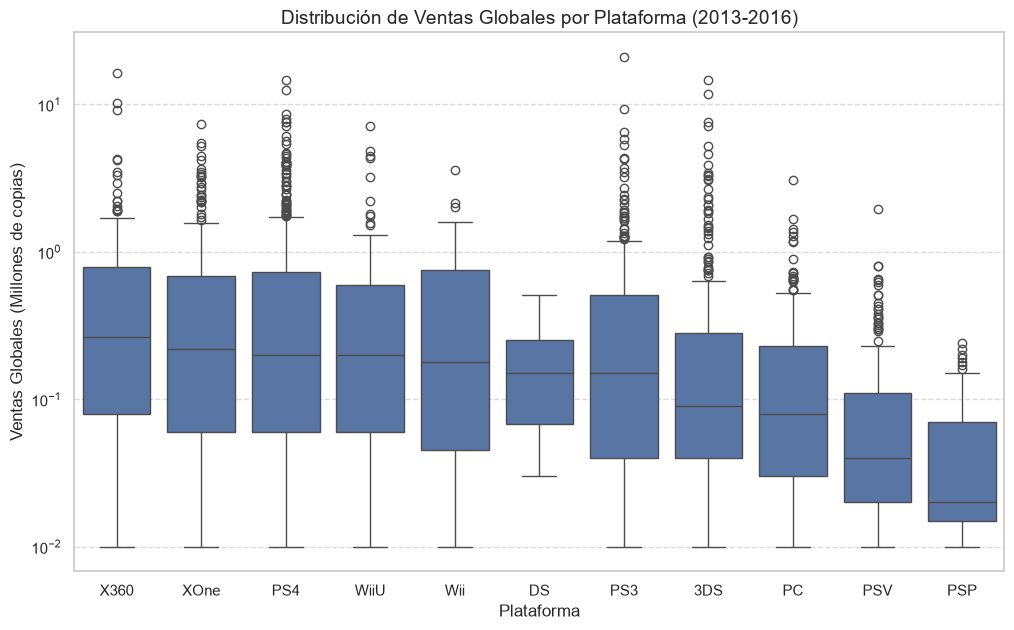

In [20]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_relevante, x='platform', y='total_sales', order=df_relevante.groupby('platform')['total_sales'].median().sort_values(ascending=False).index)
plt.title('Distribución de Ventas Globales por Plataforma (2013-2016)', fontsize=14)
plt.xlabel('Plataforma', fontsize=12)
plt.ylabel('Ventas Globales (Millones de copias)', fontsize=12)
plt.yscale('log') 
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.show()

Una vez que contamos con nuestro diagrama de caja procedemos a responder cada una de las preguntas dentro de este inciso.

La respuesta hacía la pregunta de que si ¿Son significativas las diferecias en las ventas?: La respuesta es SI y la razon principal es porque son estadisticamente significativas y para llegar a esta respuesta se tuvo que observar de forma detenida cada uno de los diagramas de cajas y a raíz de observar detenidamente se encontraron 2 aspectos que considero importantes mencionar:
El primer punto es Dispersión y Valores Atípicos: La totalidad de las plataformas líderes (PS4, XBox One, Xbox y PS3); si observamos tienen una cantidad demasiado grande en cuestión de valores atípicos y que significa estó? Significa que la gran mayoria de los juegos logran vender menos de 1 millón de copias, pero basta con unos pocos éxitos comerciales que rompan completamente la escala.

Size of the box (Tamaños de las cajas): Como podemos observar realmente las cajas de PSV y Wii no son tan notables en el Y versus a las cajas de una PS4 o un Xbox One donde las cajas de estas consolas hablan por si solas debido y es algo que esta demostrado el rendimiento generalmente de los videojuegos en las consolas de la actualidad son mucho mas superiores.

La respuesta a la siguiente pregunta ¿Qué sucede con las ventas promedio en varias plataformas?: Podemos responderla de la siguiente manera:
Primer punto Distorsión por éxitos comerciales: Aqui las ventas juegan un papel importante porque en promedio son altas en todas las plataformas debido a como bien lo mencionamos anteriormente por valores atípicos, algo que es visible y que impacta aun en consolas antiguas como pueden ser PS3 y Xbpx 360.

Desigualdad entre plataformas comerciales y portátiles: Es importante recalcar esta parte ya que se busca ver que plataformas, que datos en cuestión ventas y estadistico nos acerca mas hacía nuestro módelo para 2017 y durante todo esté análisis de datos se mencionó una y otra véz las plataformas que liderean esta parte (PS4 y Xbox One) sostenido por bases solidas como lo es una gran lista de clientes potenciales. Mientras que los portátiles como PSV y 3DS son todo lo contrario que solo acumulan titulos de juegos con ventas por muy debajo de cara a las de PS4 y Xbox One y demasiado cercanas a cero.



Para el siguiente inciso los resultados fueron los siguientes.
Nota todo fue hecho con nuestra tabla donde solo estamos haciendo el modelo para 2017.
Procedemos a crear el gráfico de dispérsión y enseguida la correlación entre las reseñas y las ventas, adjuntando de igual manera mis conclusiones.

In [21]:
df_relevante.info()

<class 'pandas.DataFrame'>
Index: 2233 entries, 16 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             2233 non-null   object  
 1   platform         2233 non-null   category
 2   year_of_release  2233 non-null   int64   
 3   genre            2233 non-null   category
 4   na_sales         2233 non-null   float64 
 5   eu_sales         2233 non-null   float64 
 6   jp_sales         2233 non-null   float64 
 7   other_sales      2233 non-null   float64 
 8   critic_score     991 non-null    float64 
 9   user_score       1192 non-null   float64 
 10  rating           2233 non-null   object  
 11  total_sales      2233 non-null   float64 
dtypes: category(2), float64(7), int64(1), object(2)
memory usage: 197.8+ KB


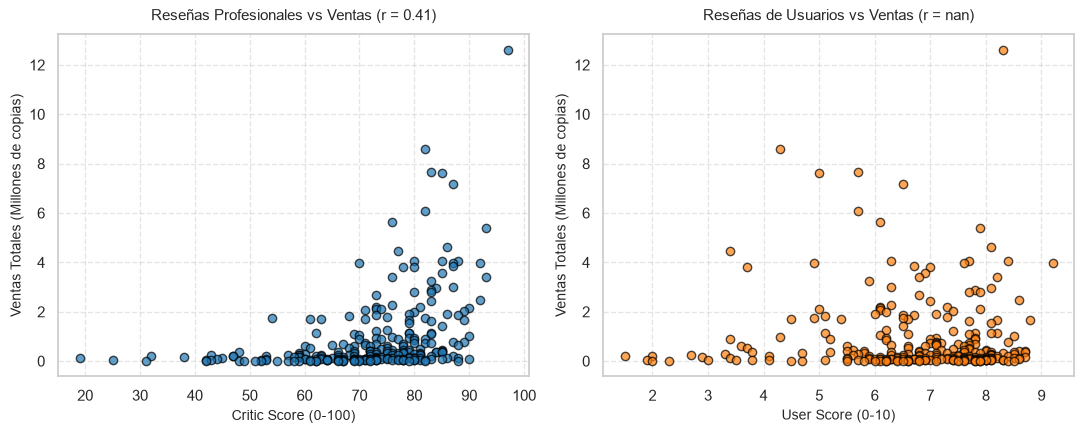

In [22]:
# Como primer paso vamos solamente a copiar la plataforma con la que harmeos el resto de lo que se nos solicita:
df_game_ps4 = df_relevante[df_relevante['platform'] == 'PS4'].copy()
# Aqui realizamos un limpieza de datos obligatoria y conversión de columnas a  tipo de dato numerico.
df_game_ps4['critic_score'] = pd.to_numeric(df_game_ps4['critic_score'], errors='coerce')
df_game_ps4['user_score'] = pd.to_numeric(df_game_ps4['user_score'], errors='coerce')
df_game_ps4['total_sales'] = pd.to_numeric(df_game_ps4['total_sales'], errors='coerce')

# Eliminamos filas donde falten ventas o puntuaciones necesarias:
df_critic = df_game_ps4.dropna(subset = ['critic_score', 'total_sales'])
df_user = df_game_ps4.dropna(subset = ['user_score', 'total_sales'])

# Calculamos los coeficientes de correlacón.
corr_critic = np.corrcoef(df_critic['critic_score'], df_critic['total_sales'])[0, 1]
corr_user = np.corrcoef(df_user['critic_score'], df_user['total_sales'])[0, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.scatter(
    df_critic['critic_score'], 
    df_critic['total_sales'], 
    color='#1f77b4', 
    alpha=0.7, 
    edgecolors='black', 
    label='Juegos PS4'
)
ax1.set_title(f'Reseñas Profesionales vs Ventas (r = {corr_critic:.2f})', fontsize=11, pad=10)
ax1.set_xlabel('Critic Score (0-100)', fontsize=10)
ax1.set_ylabel('Ventas Totales (Millones de copias)', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.scatter(
    df_user['user_score'], 
    df_user['total_sales'], 
    color='#ff7f0e', 
    alpha=0.7, 
    edgecolors='black', 
    label='Juegos PS4'
)
ax2.set_title(f'Reseñas de Usuarios vs Ventas (r = {corr_user:.2f})', fontsize=11, pad=10)
ax2.set_xlabel('User Score (0-10)', fontsize=10)
ax2.set_ylabel('Ventas Totales (Millones de copias)', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Conclusiones referente a este iniciso son relevantes y resumidas para el análisis.

La determinación profesional impulsa el éxito comercial: Existe una clara tendencia ascendente en el primer gráfico. A mayor puntuación de la crítica especializada (Critic Score), las ventas aumentan. Las notas superiores a 85 puntos actúan como un catalizador indispensable para que un juego alcance el estatus de superventas (como Grand Theft Auto V con sus 12.62 millones de copias en PS4).
Opinión del usuario final no determina las ventas masivas: El segundo gráfico muestra una dispersión completamente caótica y horizontal. Esto demuestra que las calificaciones de los usuarios (User Score) no guardan relación con el éxito en taquilla. Juegos con calificaciones medias o bajas de usuarios logran vender millones debido a campañas de marketing masivas o preventas previas al lanzamiento.

In [23]:
df_games

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,<NA>,NaN,Unknown,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,<NA>,NaN,Unknown,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,<NA>,NaN,Unknown,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,<NA>,NaN,Unknown,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,<NA>,NaN,Unknown,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,<NA>,NaN,Unknown,0.01


A continuación, se abordan las siguientes preguntas clave para profundizar en el análisis operativo y comercial de la tienda online Ice.

Para responder a esta pregunta, se comparo el rendimiento de los mismos titulos de la columna (name) en diferentes consolas tomando como referencia la columna (platform) se hizo de esta manera ya que se solicita un comparativa de ventas de los mismos juegos en otras plataformas y de lo cual se logro extraer las siguientes comparativas, cabe mencionar que esto revela patrones estrcuturales de cara a cómo se compporta esta gran industria y por ende la preferencia que hay por aprte de los consumidores:

Por poner un ejemplo (Wii Sport, Super Mario Bros, Pokemon) cuentan con ventas masivas pero a diferencia y esta es la primera comparativa es que tienen un candado es decir que solo funcionan dentro de sus propias plataformas, alo que hace que los consumidores consuman sus productos hablando en terminos de consolas (plataformas) a lo cuál le llamo "Distribución Exclusiva".

Títulos clásicos: Bien dicen por hay que lo clasico nunca pasa de moda y esto aplica igual aquí ya que reinventar o remasterizar un juego clásico siempre ayuda a los fabricantes de platafomas y de desarrollo de videojuegos hacer crecer nuevamente sus números y enfilarse en el top de los mejores juegos y plataforms.

A continuación se representa de forma grafica lo descrito aquí:

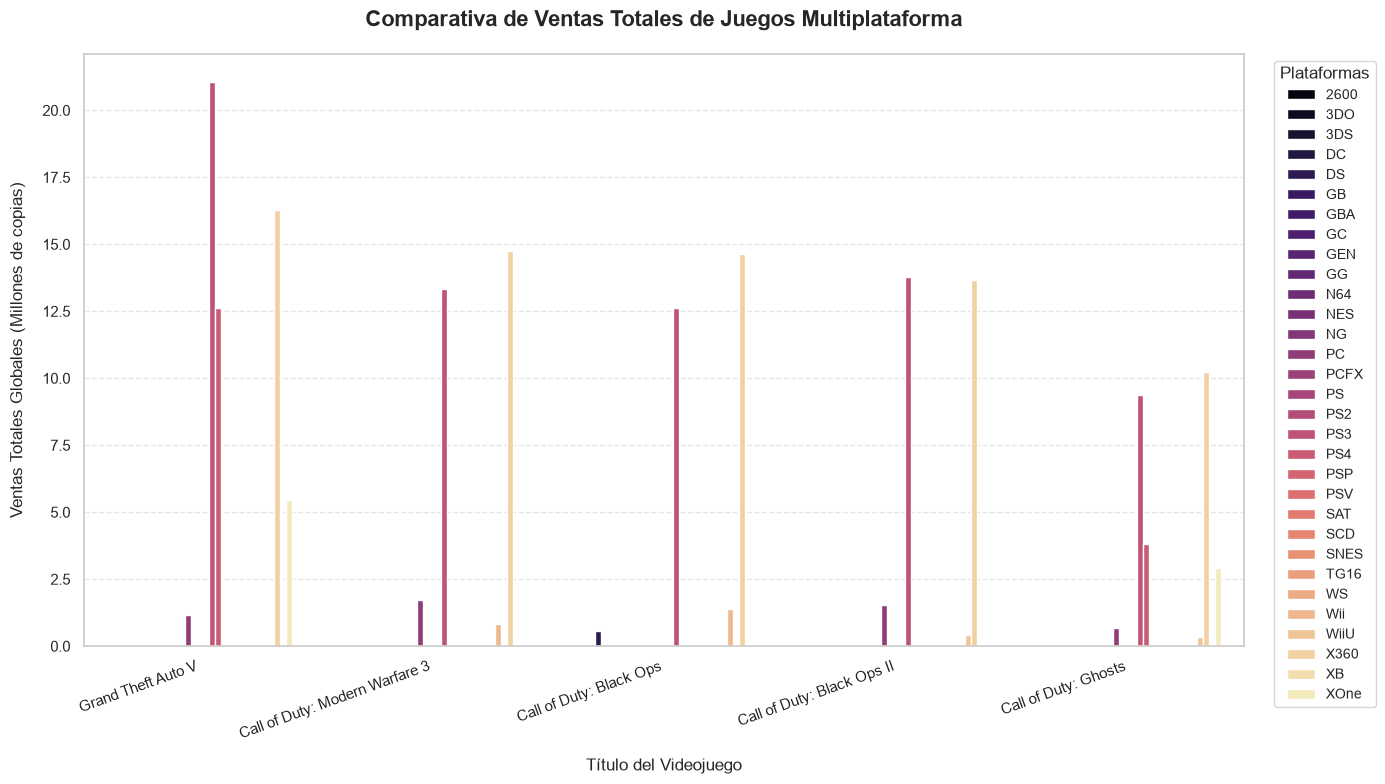

In [24]:
# Se realizo una grafica de barras que ayuda a comparar las ventas de los mismos juegos en diferentes plataformas.
# Esta grafica se obtuvo usando los datos del Data inicial.
df_games['name'] = df_games['name'].str.strip()
df_games['total_sales'] = pd.to_numeric(df_games['total_sales'], errors='coerce')

juegos_por_plataforma = df_games.groupby('name')['platform'].nunique()

juegos_multi = juegos_por_plataforma[juegos_por_plataforma >= 3].index

top_juegos_multi = (
    df_games[df_games['name'].isin(juegos_multi)]
    .groupby('name')['total_sales'].sum()
    .nlargest(5).index
)

df_filtrado = df_games[df_games['name'].isin(top_juegos_multi)]

plt.figure(figsize=(14, 8))


sns.barplot(
    data=df_filtrado, 
    x='name', 
    y='total_sales', 
    hue='platform', 
    palette='magma' 
)


plt.title('Comparativa de Ventas Totales de Juegos Multiplataforma', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Título del Videojuego', fontsize=12, labelpad=12)
plt.ylabel('Ventas Totales Globales (Millones de copias)', fontsize=12, labelpad=12)


plt.legend(title='Plataformas', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)


plt.xticks(rotation=20, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5) # Líneas de fondo solo horizontales


plt.tight_layout()
plt.show()

¿Qué se puede decir de los géneros más rentables? Para esta pregunta se responde en dos partes la primera:

Acción y Deportes dominantes del mercado: Podemos decir con certeza que estos géneros son los más rentables hablando en el total de ventas globales. Tambien podemos decir que son el soporte que mantiene la mayor cantidad de lanzamientos durante la historia de los videojuegos y son las mismas que acumulan la mayor cantidad de ingresos monetarios.

Shooters y Platform: Estos son géneros que tienen menos títulos de forma individual en el mercado sin embargo juegos como (Call Of Duty o Super MArio Bros), son juegos que realmente generan ingresos masivos y concentrados.

¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

Segmento Masivo de Alta Rentabilidad: Los géneros de action, shoooter, sports y platform podemos observar que lideran las ventas globales debido a su atractivo universal y mecánicas dinámicas que facilitan la comercialización masiva a gran escala.

Segmento de Nicho y Rendimiento Moerado: Los géneros restantes (RPG, Racing, Fighting, Adventure, Simulation, Strategy, Puzzle) generan ingresos menores o condicionados, limitados por preferencias geográficas muy marcadas o por dinámicas de juego especializadas para públicos reducidos.



Responde como formulaste las hipótesis nula y alternativa?. 
Para la primera pregunta, se estrucutro de forma matematica bilateral para determinar la existencia o ausencia de diferencias significativas.
Hipótesis 1. (Plataformas):

Hipótesis Nula: Muestra que las califaciones promedio de los usuarios para ambas plataformas son estadisticamente iguales.
Hipótesis Alternativa: Plantea que las calificaciones promedio de los usuarios para ambas plataformas son diferentes.
Hipótesis 2 (Géneros):

Hipótesis Nula: Plantea que las calificaciones promedio de los usuarios para ambos géneros son estadísticamente iguales.
Hipótesis Alternativa: Plantea que las calificaciones promedio de los usuarios para ambos géneros son diferentes.
Qué criterio utilizaste para probar las hipótesis y por qué.
Se utilizó una Prueba t de Student para muestras independientes mejora conocida como (Prueba de Welch)

Se decidio tomar este criterio ya que las muestras de calificaciones de cada grupo no tenían el mismo tamaño de filas ni la misma variabilidad. Y para lograr un mejor resultado la "Prueba de Welch" corrige estas diferencia genericas del dataset y logra evitar sesgos que esto ayuda a garantizar un resultado exacto.

In [25]:
#Test aplicado a Data
df_games['critic_score'] = pd.to_numeric(df_games['critic_score'], errors='coerce')

df_games["critic_score"] = pd.to_numeric(
    df_games["critic_score"], errors="coerce"
)

action_scores = df_games[df_games["genre"] == "Action"]["critic_score"].dropna()
sports_scores = df_games[df_games["genre"] == "Sports"]["critic_score"].dropna()

stat, p_value = stats.ttest_ind(action_scores, sports_scores, equal_var=False)

print("=== RESULTADOS DEL TEST ESTADÍSTICO ===")
print(f"Promedio Acción: {action_scores.mean():.2f} (n = {len(action_scores)})")
print(f"Promedio Deportes: {sports_scores.mean():.2f} (n = {len(sports_scores)})")
print(f"Estadístico t: {stat:.4f}")
print(f"Valor p (p-value): {p_value}")

alpha = 0.05
if p_value < alpha:
    print("\nConclusión: Se rechaza la hipótesis nula (H0). Existe una diferencia estadísticamente significativa entre las calificaciones de ambos géneros.")
else:
    print("\nConclusión: No se puede rechazar la hipótesis nula (H0). No hay evidencia estadística suficiente para afirmar que las calificaciones sean diferentes.")

#print(f"T-statistic: {stat}")
#print(f"P-value: {p_value}")

=== RESULTADOS DEL TEST ESTADÍSTICO ===
Promedio Acción: 66.68 (n = 1851)
Promedio Deportes: 71.99 (n = 1165)
Estadístico t: -10.1434
Valor p (p-value): 1.0115459518638404e-23

Conclusión: Se rechaza la hipótesis nula (H0). Existe una diferencia estadísticamente significativa entre las calificaciones de ambos géneros.


Conclusión general del proyecto.

